In [4]:
from ib_insync import *
import random
import asyncio
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_excel('/Users/thijsmanuel/Documents/cuhk_classes/4130/term_paper/vinci/Data/hsi_vol.xlsx').set_index('date')
hsi = df['2800.HK']

log_ret = pd.read_excel('/Users/thijsmanuel/Documents/cuhk_classes/4130/term_paper/vinci/Data/hsi_log_ret.xlsx').set_index('date')

In [6]:
log_ret

,2800.HK
date,
2007-05-02,0.004895
2007-05-03,0.014542
2007-05-04,0.004801
2007-05-07,0.005731
2007-05-08,-0.007168
...,...
2025-12-02,0.001908
2025-12-03,-0.011503
2025-12-04,0.008449


In [7]:
split_date = '2021-12-31'

In [8]:
from arch import arch_model

model = arch_model(log_ret*100, vol='GARCH', p=1, q=1, o=1)

res = model.fit(disp='off', last_obs=split_date)

forecasts = res.forecast(horizon=21, start=split_date, method='simulation', simulations=1000, ).variance


sigma2_21_forecast = forecasts.sum(axis=1)
y_pred = 0.5 * np.log(sigma2_21_forecast/ (100*100)) 


In [9]:
res

                   Constant Mean - GJR-GARCH Model Results                    
Dep. Variable:                2800.HK   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:               -5995.51
Distribution:                  Normal   AIC:                           12001.0
Method:            Maximum Likelihood   BIC:                           12032.0
                                        No. Observations:                 3616
Date:                Mon, Dec 08 2025   Df Residuals:                     3615
Time:                        18:39:39   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         8.0640e-03  1.933e-02      0.417      0.677 

In [10]:
y_pred

date
2021-12-31   -2.924080
2022-01-03   -2.939134
2022-01-04   -2.962584
2022-01-05   -2.899669
2022-01-06   -2.915169
                ...   
2025-12-02   -2.897208
2025-12-03   -2.886618
2025-12-04   -2.900394
2025-12-05   -2.921194
2025-12-08   -2.909542
Length: 967, dtype: float64

In [11]:
y_true = hsi['2021-12-31':]

In [12]:
valid_idx = y_true.index.intersection(y_pred.index)
y_true = y_true.loc[valid_idx]
y_pred = y_pred.loc[valid_idx]

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
print("MSE:", round(mse,3))
print("MAE:", round(mae,3))
print("R2:", round(r2,3))

MSE: 0.126
MAE: 0.254
R2: -0.21


In [14]:
ann_true = np.exp(y_true) * np.sqrt(12) *100
ann_pred = np.exp(y_pred) * np.sqrt(12) *100

In [15]:
ann_true

date
2021-12-31    21.579091
2022-01-03    23.813496
2022-01-04    23.813036
2022-01-05    23.298814
2022-01-06    24.100729
                ...    
2025-11-03    17.940729
2025-11-04    18.204833
2025-11-05    18.438105
2025-11-06    17.002907
2025-11-07    17.067161
Name: 2800.HK, Length: 946, dtype: float64

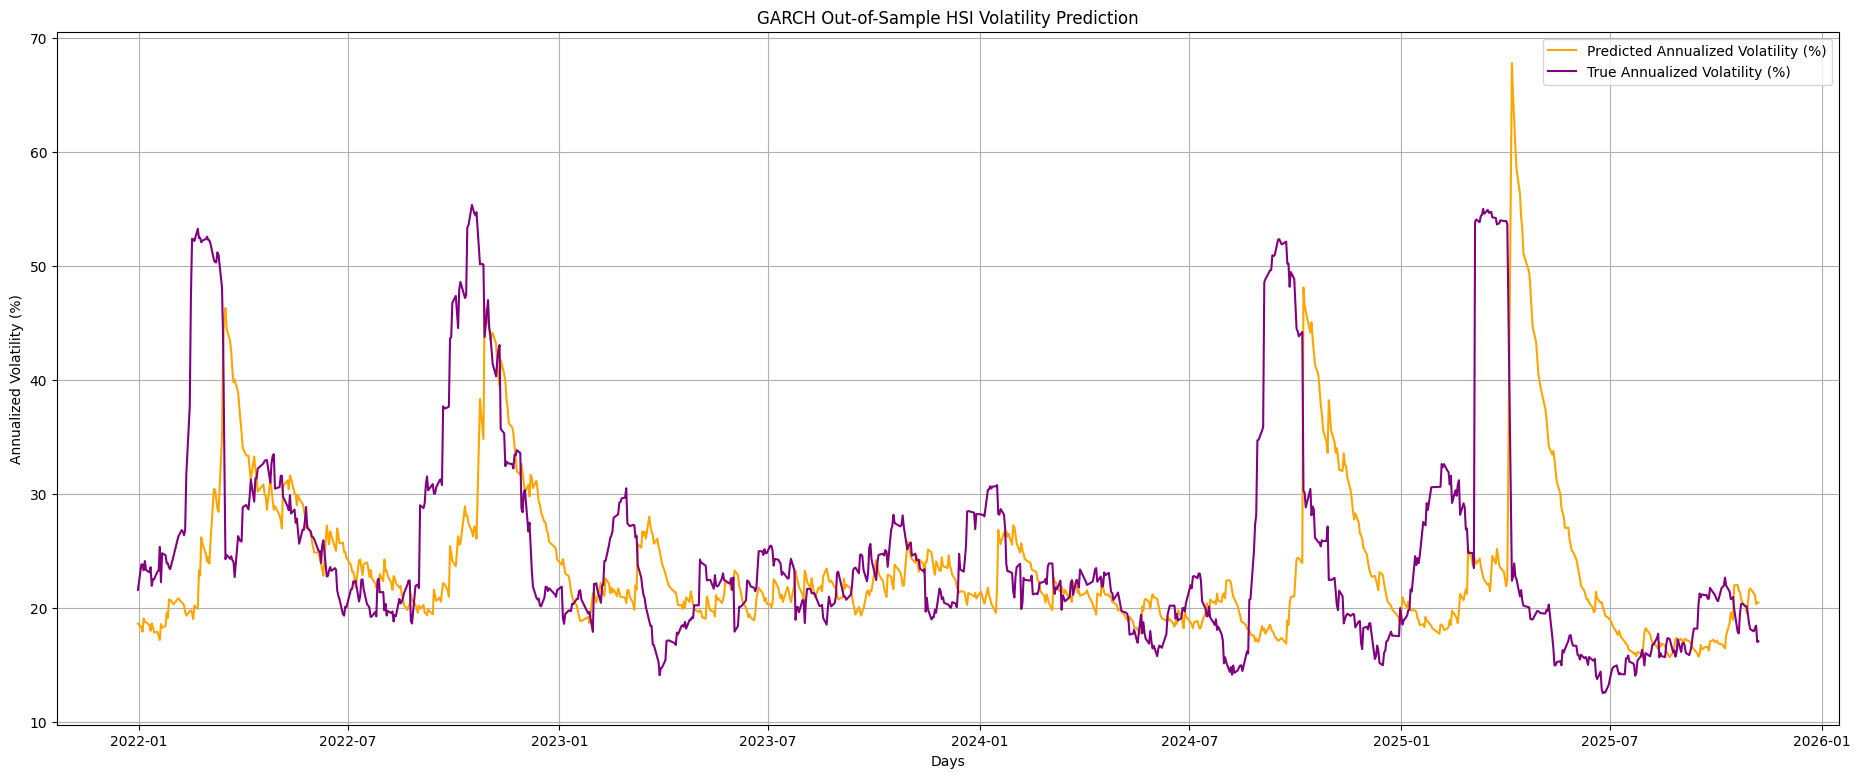

In [16]:
plt.figure(figsize=(23,9))

plt.plot(ann_pred, label='Predicted Annualized Volatility (%)', c='orange')
plt.plot(ann_true, label='True Annualized Volatility (%)', c='purple')
plt.title('GARCH Out-of-Sample HSI Volatility Prediction')
plt.xlabel('Days')
plt.ylabel('Annualized Volatility (%)')
plt.legend()
plt.grid()

In [17]:
# y_pred.to_excel('/Users/thijsmanuel/Documents/cuhk_classes/4130/term_paper/vinci/test_results/garch_oos_pred.xlsx')